# Cluster models

## Clustering models


Unsupervised models - unlabeled data (no predetermined answers)
- How do you know if it's a reliable model?
- Method of grouping/clustering is arbitrary  
  
It is arbitrary, but there has to be something to measure quality...  
There are a few things to look at. We will specifically answer:  
"How do I know how many clusters there are?"  
- The goal is to minimize the size of each cluster while simultaneously minimizing the number of clusters  
  
The most well-used method is the WCSS (Within-cluster Sum of Squares) measure and the "Elbow Method"


## WCSS


Based on SSE
- For each cluster, calculate
- Measure the squared distance $(x - \mu_i)^2$ for each point in the cluster
- Add the squared distances together  
$\sum_{x \epsilon C_i} {(x - \mu_i)^2}$  
- Add these values together across all clusters  
  
$ WCSS = \sum_i \sum_{x \epsilon C_i} {(x - \mu_i)^2}$  
  
The goals:
- Minimize the distances between points within a cluster
- Minimize the number of clusters (Maximize the distance between clusters)  
We use the "Elbow Method" to demonstrate this.

## KMeans

It is based on the idea of finding the middle of cluster and then grouping all datapoints to the nearest cluster  
  
Algorithm:
1. Determine the number of clusters/centroids needed for your data
2. Randomly assign points to a cluster
3. Find the midpoint of your clusters and move your centroids to those midpoints
4. Measure the distance from every point to each centroid and assign each point to the nearest centroid
5. Repeat steps 3-4 until the updates to your centroids fall below some threshold

In [1]:
import numpy as np
import matplotlib.pyplot as plt


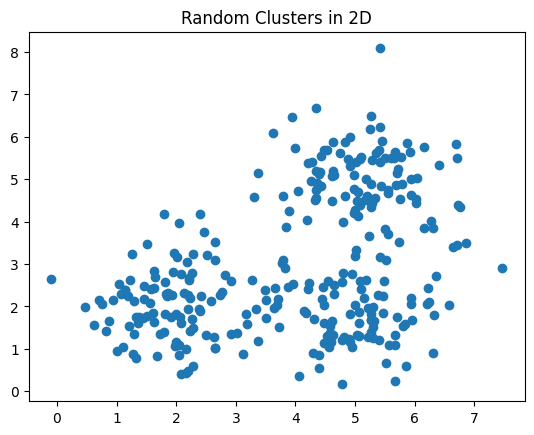

In [3]:
# Create our dataset
np.random.seed(42)

# Number of points per cluster
points_per_cluster = 100

# Random cluster centers
centers = np.array([[2,2], [5,5], [5,2]])

# Spread of points in each cluster
cluster_std = 0.8

# Generate clusters
clusters = []
for center in centers:
    cluster = np.random.randn(points_per_cluster, 2) * cluster_std + center
    clusters.append(cluster)

# Combine data
data = np.vstack(clusters)

# Plot the dataset
plt.figure()
plt.scatter(data[:, 0], data[:, 1])
plt.title("Random Clusters in 2D")
plt.show()

In [13]:
# 1. Determine the number of clusters/centroids needed for your data
k = 3


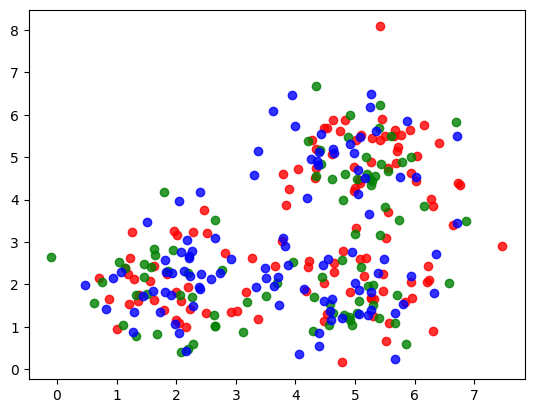

In [14]:
# 2. Randomly assign points to a cluster
assigned_cluster = np.random.randint(0, k, size=len(data))
plt.figure()
colors = ['red', 'green', 'blue']
for i in range(k):
    cluster_points = data[assigned_cluster == i]
    if len(cluster_points) > 0:
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}', alpha=0.8)
plt.show()

In [15]:
# 3. Find the midpoint of your clusters and move your centroids to those midpoints
centroids = []
for i in range(k):
    cluster_points = data[assigned_cluster == i]
    centroids.append(cluster_points.mean(axis=0))

def visualize_clusters(data, assigned_cluster, centroids):
    plt.figure()
    colors = ['red', 'green', 'blue']

    for i in range(k):
        cluster_points = data[assigned_cluster == i]
        if len(cluster_points) > 0:
            plt.scatter(cluster_points[:, 0], cluster_points[:, 1], color=colors[i], label=f'Cluster {i+1}', alpha=0.8)
    plt.show()

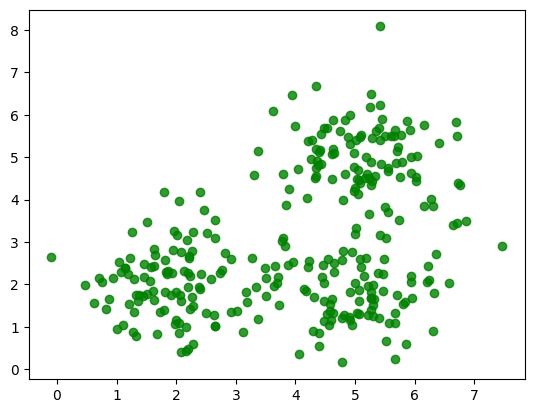

In [26]:
# 4. Measure the distance from every point to each centroid and assign each point to the nearest centroid
def euclidean_distance(point, centroid):
    return np.sqrt(np.sum((point - centroid) ** 2, axis=1))

def assign_clusters(data, centroids):
    new_cluster = np.zeros(len(data), dtype=int)
    for i, point in enumerate(data):
        distances = euclidean_distance(point, centroids)
        new_cluster[i] = np.argmin(distances)
    return new_cluster

assigned_cluster = assign_clusters(data, centroids)

visualize_clusters(data, assigned_cluster, centroids)

C:\Users\caelc\AppData\Local\Temp\ipykernel_11120\1797048682.py:6: RuntimeWarning: Mean of empty slice
  centroids.append(cluster_points.mean(axis=0))
C:\Users\caelc\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


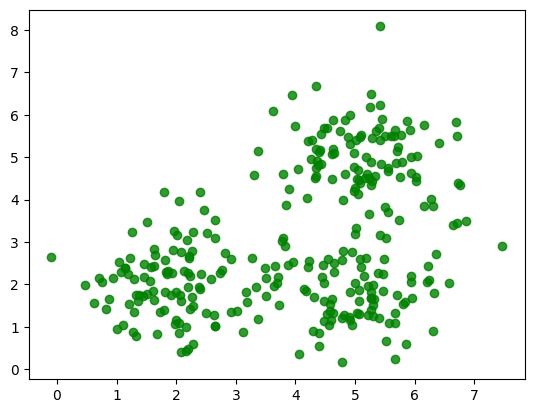

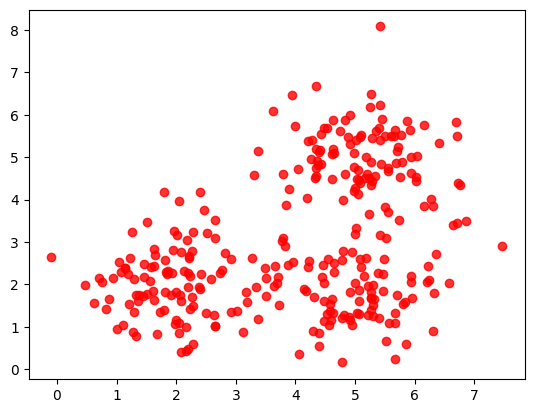

In [27]:
# 5. Repeat steps 3-4 until the updates to your centroids fall below some threshold
# Step 3: Update centroids
centroids = []
for i in range(k):
    cluster_points = data[assigned_cluster == i]
    centroids.append(cluster_points.mean(axis=0))

visualize_clusters(data, assigned_cluster, centroids)

# Step 4: Update points to clusters
assigned_cluster = assign_clusters(data, centroids)

visualize_clusters(data, assigned_cluster, centroids)

## The Elbow Method

Graph the WCSS on y-axis and # of clusters on x-axis  
After the "Elbow", there is no real benefit to increasing the number of clusters
- The "elbow" point represents the ideal number of clusters

## Hierarchical Clustering